# <span style = "color:green"> Data Aggregation and Preparation </span>

### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [48]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) in MW
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})

# --- GENERATOR DATA (WITH FIXED ALPHAS) ---
# Col 0: Bus ID | Col 1: Base Pg | Col 8: Pmax (MW) | Col 9: Pmin (MW)
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 1, 8, 9]].rename(columns={
    0: 'bus_id', 
    1: 'Pg_base_mw', 
    8: 'Pmax_mw', 
    9: 'Pmin_mw'
})

# 1. Calculate available headroom for each generator
gen_limits['headroom_mw'] = gen_limits['Pmax_mw'] - gen_limits['Pg_base_mw']

# 2. Safety clip: Ensure no negative headroom (in case of MATPOWER rounding quirks)
gen_limits['headroom_mw'] = gen_limits['headroom_mw'].clip(lower=0.0)

# 3. Calculate the fixed alpha (Participation Factor)
total_headroom = gen_limits['headroom_mw'].sum()

if total_headroom > 0:
    gen_limits['alpha_fixed'] = gen_limits['headroom_mw'] / total_headroom
else:
    # Fallback if no headroom exists system-wide (unlikely in standard cases)
    gen_limits['alpha_fixed'] = 1.0 / len(gen_limits)

print("Fixed Alpha values calculated successfully. Top 5 contributors:")
print(gen_limits[['bus_id', 'Pg_base_mw', 'Pmax_mw', 'alpha_fixed']].sort_values('alpha_fixed', ascending=False).head())

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 3: Reactance (x) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})

# Calculate Susceptance (B = 1/x) for your DC-OPF B-matrix
branch_data['B_susceptance'] = 1.0 / branch_data['x_reactance']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())

Fixed Alpha values calculated successfully. Top 5 contributors:
    bus_id  Pg_base_mw  Pmax_mw  alpha_fixed
29    69.0       591.0   1182.0     0.181427
28    66.0       392.0    784.0     0.120338
44   100.0       326.5    653.0     0.100230
39    89.0       318.5    637.0     0.097774
36    80.0       254.5    509.0     0.078127
Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  B_susceptance
0       1.0     2.0      0.09990             151.0      10.010010
1       1.0     3.0      0.04240             151.0      23.584906
2       4.0     5.0      0.00798             176.0     125.313283
3       3.0     5.0      0.10800             175.0       9.259259
4       5.0     6.0      0.05400             176.0      18.518519


### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [49]:
import pandas as pd
import numpy as np
import requests
import io
import time
from gridstatus import CAISO

START = "2022-02-03"
END   = "2023-02-03"

# --- 1. CAISO 5-minute system demand ---
iso = CAISO()
load = iso.get_load(
    start=pd.Timestamp(START, tz="US/Pacific"),
    end=pd.Timestamp(END,   tz="US/Pacific"),
)

load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
load["timestamp"] = (pd.to_datetime(load["timestamp"])
                      .dt.tz_convert("US/Pacific")
                      .dt.tz_localize(None))
load["timestamp"] = load["timestamp"].dt.round("5min")
load = (load[["timestamp", "load_mw"]]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .set_index("timestamp"))

# =====================================================================
# 2. ROBUST LAX ASOS: Chunked 5-minute temperature + RH
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=5): # Increased retries just in case
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=LAX&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/Los_Angeles&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    for attempt in range(retries):
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
            
        # Catch BOTH 503 (Server Busy) and 429 (Too Many Requests)
        elif response.status_code in [503, 429]:
            wait_time = 2 ** (attempt + 1) + 2  # Added a small buffer
            print(f"  [!] HTTP {response.status_code}. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        else:
            response.raise_for_status()
            
    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")

print("Fetching weather data in 30-day chunks to prevent IEM server timeouts...")

# Create 30-day intervals to loop through
date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
if pd.Timestamp(END) not in date_chunks:
    date_chunks.append(pd.Timestamp(END))

wx_chunks = []
for i in range(len(date_chunks) - 1):
    s = date_chunks[i]
    e = date_chunks[i+1]
    print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
    
    chunk_df = fetch_asos_chunk(s, e)
    wx_chunks.append(chunk_df)
    time.sleep(3)  # Polite pause between chunks

# Combine all the chunks into one DataFrame
wx = pd.concat(wx_chunks, ignore_index=True)
wx = wx.drop_duplicates(subset=["valid"])

# Continue with your exact original data processing
wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
wx["temperature"] = (wx["temp_f"] - 32) * 5/9            

T  = wx["temperature"]
RH = wx["rh_pct"]
wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

wx = wx[["timestamp", "temperature", "humidity"]].dropna()
wx["timestamp"] = wx["timestamp"].dt.round("5min")
wx = (wx.groupby("timestamp").mean().sort_index())

grid = pd.date_range(load.index.min(), load.index.max(), freq="5min")
wx = wx.reindex(grid).interpolate("time", limit=12)   

# --- 3. Merge + sanity check ---
df = load.join(wx, how="inner")
print(f"\nLoad rows:    {len(load):,}")
print(f"Weather rows: {len(wx.dropna()):,}")
print(f"Merged rows:  {len(df):,}   (expect ~105,000 for one year of 5-min)")

100%|██████████| 365/365 [02:05<00:00,  2.91it/s]


Fetching weather data in 30-day chunks to prevent IEM server timeouts...
  -> Pulling chunk: 2022-02-03 to 2022-03-05
  -> Pulling chunk: 2022-03-05 to 2022-04-04
  -> Pulling chunk: 2022-04-04 to 2022-05-04
  -> Pulling chunk: 2022-05-04 to 2022-06-03
  -> Pulling chunk: 2022-06-03 to 2022-07-03
  -> Pulling chunk: 2022-07-03 to 2022-08-02
  -> Pulling chunk: 2022-08-02 to 2022-09-01
  -> Pulling chunk: 2022-09-01 to 2022-10-01
  -> Pulling chunk: 2022-10-01 to 2022-10-31
  -> Pulling chunk: 2022-10-31 to 2022-11-30
  -> Pulling chunk: 2022-11-30 to 2022-12-30
  -> Pulling chunk: 2022-12-30 to 2023-01-29
  -> Pulling chunk: 2023-01-29 to 2023-02-03

Load rows:    105,092
Weather rows: 105,091
Merged rows:  105,092   (expect ~105,000 for one year of 5-min)


### 3. Data Aggregation and Scaling

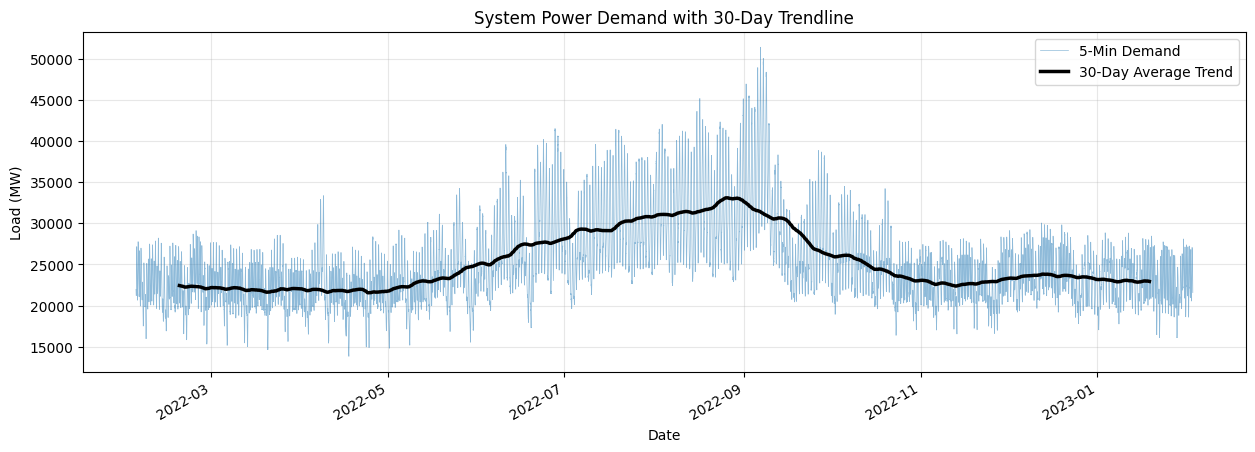

In [72]:
import matplotlib.pyplot as plt

# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()

In [73]:
# 1. Merge and clean
df = load.join(wx, how="inner")
df = df.dropna()

median_load = np.median(df['load_mw'])
df['scaling_factor'] = df['load_mw'] / median_load

abs_max_scale = gen_limits['Pmax_mw'].sum() / nodal_demand['Pd_mw'].sum()
exceedance_pct = sum(df['scaling_factor'] >= abs_max_scale) / len(df['scaling_factor']) * 100

print(f"{exceedance_pct:.2f}% of time more power than gen can handle")

4.27% of time more power than gen can handle


In [74]:
## Identify Generator limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 1.06
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()
current_peak = df['scaling_factor'].max()

if current_peak > max_scaling_factor:
    rescale_factor = max_scaling_factor / current_peak
    df['scaling_factor'] = df['scaling_factor'] * rescale_factor

In [75]:
exceedance_pct = sum(df['scaling_factor'] >= abs_max_scale) / len(df['scaling_factor']) * 100
print(f"{exceedance_pct:.2f}% of time more power than gen can handle post adjustment")

0.09% of time more power than gen can handle post adjustment


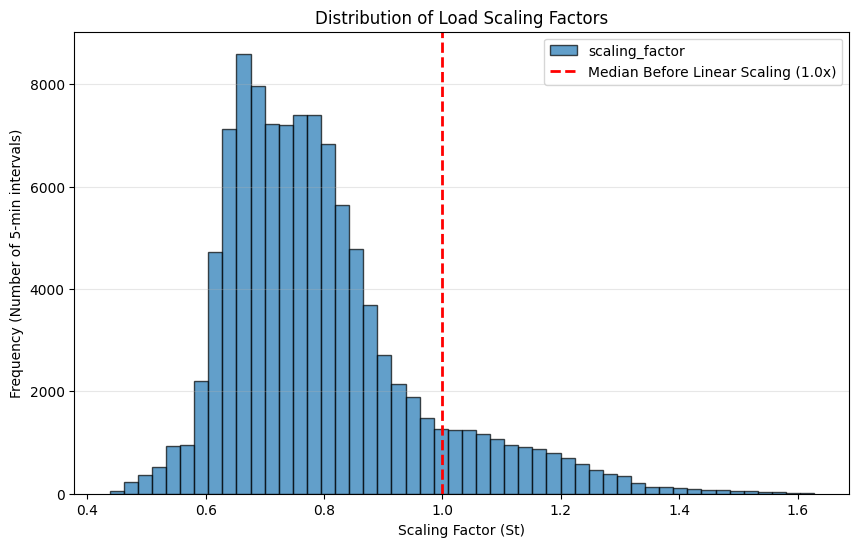

In [76]:
### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

In [77]:
## Scale IEEE 118 test bus today to follow the variance of our data

scaled_nodal_demand = pd.DataFrame(
    np.outer(df['scaling_factor'], nodal_demand['Pd_mw']),
    index=df.index,                 # Your 105,000 timestamps become the rows
    columns=nodal_demand['bus_id']  # Your 118 bus IDs become the columns
)


# <span style = "color:green"> Define Our Two Stage Optimization Problem </span>

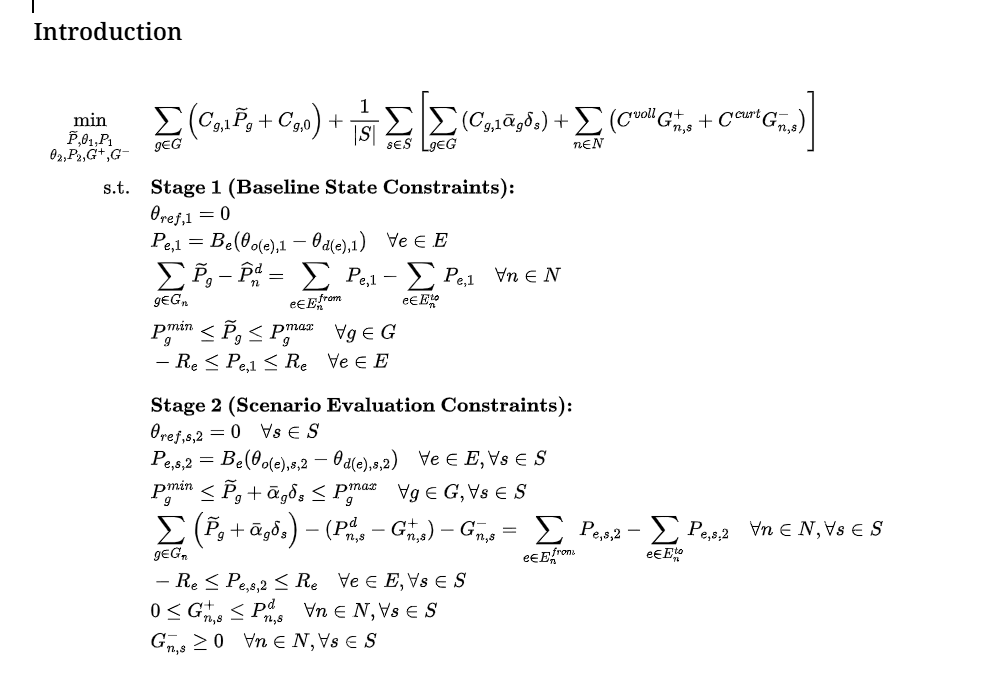

In [78]:
 ## Define Parameters
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# -----------------------------------------------------------------------------
# 1. Build index maps and system data
# -----------------------------------------------------------------------------
bus_ids   = nodal_demand['bus_id'].astype(int).values
N_BUS     = len(bus_ids)
bus_idx   = {int(b): i for i, b in enumerate(bus_ids)}

gen_bus     = gen_limits['bus_id'].astype(int).values
gen_bus_idx = np.array([bus_idx[int(b)] for b in gen_bus])
Pg_min      = gen_limits['Pmin_mw'].values
Pg_max      = gen_limits['Pmax_mw'].values
c1          = gen_costs['cost_linear'].values
c0          = gen_costs['cost_constant'].values
N_GEN       = len(gen_bus)
from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values
derating_factor = 0.9
R_line   = branch_data['thermal_limit_mw'].values * derating_factor
N_LINE   = len(B_line)

SLACK  = 0
VOLL   = 5000.0 ## Load shed is typically much costlier than renewable curtailment
C_CURT = 1000.0

In [106]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — RHS UPDATED FAST CLASS
# =============================================================================
import numpy as np
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB

# ----- Sparse incidence matrices (built once, reused per solve) -----
# Generator-to-bus map: G_bus[n, g] = 1 iff generator g sits on bus n.
_G_bus_sp = sp.csr_matrix(
    (np.ones(N_GEN), (gen_bus_idx, np.arange(N_GEN))),
    shape=(N_BUS, N_GEN),
)
# Line incidence: A_inc[e, n] = +1 if line e leaves bus n, -1 if it enters.
_A_inc_sp = sp.csr_matrix(
    (
        np.concatenate([np.ones(N_LINE), -np.ones(N_LINE)]),
        (
            np.concatenate([np.arange(N_LINE), np.arange(N_LINE)]),
            np.concatenate([from_idx, to_idx]),
        ),
    ),
    shape=(N_LINE, N_BUS),
)
# Susceptance-weighted incidence so DC flow is just B_inc @ theta.
_B_inc_sp = sp.diags(B_line) @ _A_inc_sp

class FastStochasticOPF:
    """
    Persistent Gurobi model. Builds the massive Stage 1 and Stage 2 matrix exactly
    once. Allows instantaneous updates to demand parameters via .RHS and .UB.
    """
    def __init__(self, N_SCEN, voll=VOLL, c_curt=C_CURT, weights=None, verbose=False, return_lmps=False):
        self.N_SCEN = N_SCEN
        self.return_lmps = return_lmps
        
        if weights is None:
            weights = np.full(N_SCEN, 1.0 / N_SCEN)
        self.weights = np.asarray(weights, dtype=float)

        m = gp.Model("stochastic_dcopf_piecewise_4tier_fast")
        m.Params.OutputFlag = 1 if verbose else 0
        m.Params.Threads   = 0
        m.Params.Presolve  = 2
        
        # --- NEW LOGIC: Smart Method Selection ---
        if N_SCEN == 1:
            # Grid Search (Tiny Matrix): Use Dual Simplex
            m.Params.Method = 1
        else:
            # Full Evaluation (Massive Matrix): Use Barrier without Crossover
            m.Params.Method = 2
            m.Params.Crossover = -1 if return_lmps else 0

        # --- Stage 1 variables ---
        self.Pg    = m.addMVar(N_GEN,  lb=Pg_min, ub=Pg_max,    name="Pg")
        theta1     = m.addMVar(N_BUS,  lb=-GRB.INFINITY,        name="theta1")
        Pe1        = m.addMVar(N_LINE, lb=-R_line, ub=R_line,   name="Pe1")
        self.shed1 = m.addMVar(N_BUS,  lb=0.0,                  name="shed1")
        self.curt1 = m.addMVar(N_BUS,  lb=0.0,                  name="curt1")

        # --- Stage 2 variables (UB for G_shed set dynamically later) ---
        self.G_shed = m.addMVar((N_SCEN, N_BUS), lb=0.0, ub=GRB.INFINITY, name="G_shed") 
        self.G_curt = m.addMVar((N_SCEN, N_BUS), lb=0.0,                  name="G_curt")
        theta2      = m.addMVar((N_SCEN, N_BUS), lb=-GRB.INFINITY,        name="theta2")
        Pe2         = m.addMVar((N_SCEN, N_LINE),
                                lb=np.tile(-R_line, (N_SCEN, 1)),
                                ub=np.tile( R_line, (N_SCEN, 1)),
                                name="Pe2")

        # 4-tier ramp block limits
        b1, b2, b3, b4 = 0.03 * Pg_max, 0.07 * Pg_max, 0.10 * Pg_max, 0.10 * Pg_max
        ub_b1, ub_b2, ub_b3, ub_b4 = np.tile(b1, (N_SCEN, 1)), np.tile(b2, (N_SCEN, 1)), np.tile(b3, (N_SCEN, 1)), np.tile(b4, (N_SCEN, 1))

        r_up_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_up_1")
        r_up_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_up_2")
        r_up_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_up_3")
        r_up_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_up_4")
        r_dn_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_dn_1")
        r_dn_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_dn_2")
        r_dn_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_dn_3")
        r_dn_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_dn_4")

        sum_up = r_up_1 + r_up_2 + r_up_3 + r_up_4
        sum_dn = r_dn_1 + r_dn_2 + r_dn_3 + r_dn_4

        # --- Stage 1 constraints ---
        m.addConstr(theta1[SLACK] == 0, name="slack1")
        m.addConstr(Pe1 == _B_inc_sp @ theta1, name="dc_flow_1")
        
        # Save pointer to balance constraint so we can update its RHS
        self.bal1 = m.addConstr(
            _G_bus_sp @ self.Pg + self.shed1 - self.curt1 - _A_inc_sp.T @ Pe1 == np.zeros(N_BUS),
            name="balance1",
        )

        # Soft spinning reserve: 15% of forecast demand held as headroom.
        # reserve_slack absorbs any deficiency at a steep penalty (5x VOLL).
        R_REQ = 0.15
        self.R_REQ = R_REQ
        self.reserve_slack = m.addMVar(1, lb=0.0, name="reserve_slack")
        self.reserve_constr = m.addConstr(
            np.ones(N_GEN) @ self.Pg + self.reserve_slack <= Pg_max.sum(),
            name="spinning_reserve",
        )


        # --- Stage 2 constraints ---
        self.bal2_constrs = []
        for s in range(N_SCEN):
            m.addConstr(theta2[s, SLACK] == 0, name=f"slack2_{s}")
            m.addConstr(Pe2[s, :] == _B_inc_sp @ theta2[s, :], name=f"dc_flow_2_{s}")

            Pg_rt_s = self.Pg + sum_up[s, :] - sum_dn[s, :]
            m.addConstr(Pg_rt_s >= Pg_min, name=f"pg_lo_{s}")
            m.addConstr(Pg_rt_s <= Pg_max, name=f"pg_hi_{s}")

            # Algebraically identical: variables on LHS, constants (Demand) on RHS
            bal2_s = m.addConstr(
                _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
                name=f"balance2_{s}",
            )
            self.bal2_constrs.append(bal2_s)

        # --- Objective ---
        safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
        inv_pgmax   = 1.0 / safe_Pg_max 

        stage1_gen_cost   = c1 @ self.Pg + float(np.sum(c0))
        stage1_slack_cost = (10 * voll) * self.shed1.sum() + (10 * c_curt) * self.curt1.sum()
        RESERVE_PENALTY   = 5 * voll
        stage1_cost       = stage1_gen_cost + stage1_slack_cost + RESERVE_PENALTY * self.reserve_slack.sum()

        W = self.weights[:, None] 
        total_stage2_gen = (W * c1[None, :] * (sum_up - sum_dn)).sum()
        total_ramp = (
            (W * (1e3 * inv_pgmax[None, :]) * (r_up_1 + r_dn_1)).sum()
          + (W * (2e3 * inv_pgmax[None, :]) * (r_up_2 + r_dn_2)).sum()
          + (W * (1e4 * inv_pgmax[None, :]) * (r_up_3 + r_dn_3)).sum()
          + (W * (1e12 * inv_pgmax[None, :]) * (r_up_4 + r_dn_4)).sum()
        )
        total_shed_2 = voll   * (W * self.G_shed).sum()
        total_curt_2 = c_curt * (W * self.G_curt).sum()

        expected_stage2 = total_stage2_gen + total_ramp + total_shed_2 + total_curt_2
        m.setObjective(stage1_cost + expected_stage2, GRB.MINIMIZE)

        self.m = m

    def solve(self, Pd_hat, node_scen):
        """ Instantly updates the matrix memory and runs the barrier method. """
        # 1. Update Stage 1 Right-Hand Side
        self.bal1.RHS = Pd_hat

        self.reserve_constr.RHS = Pg_max.sum() - self.R_REQ * Pd_hat.sum()
        
        # 2. Update Stage 2 Shed Bounds
        self.G_shed.UB = node_scen
        
        # 3. Update Stage 2 Right-Hand Side
        for s in range(self.N_SCEN):
            self.bal2_constrs[s].RHS = node_scen[s, :]

        # Gurobi executes immediately without rebuilding
        self.m.optimize()
        if self.m.Status != GRB.OPTIMAL:
            raise RuntimeError(f"Gurobi Status={self.m.Status}")

        LMP_1 = np.asarray(self.bal1.Pi) if self.return_lmps else None

        return {
            "Pg":          self.Pg.X,
            "shed1":       self.shed1.X,
            "curt1":       self.curt1.X,
            "shed":        self.G_shed.X,
            "curt":        self.G_curt.X,
            "total_cost":  self.m.ObjVal,
            "stage1_cost": float(c1 @ self.Pg.X + np.sum(c0)),
            "LMP_1":       LMP_1,
        }

# Wrapper for backward compatibility 
def optimization_model(Pd_hat, node_scen, voll=VOLL, c_curt=C_CURT,
                       verbose=True, return_lmps=False, weights=None):
    solver = FastStochasticOPF(node_scen.shape[0], voll, c_curt, weights, verbose, return_lmps)
    return solver.solve(Pd_hat, node_scen)

# <span style="color:green">Method 1: Predict Demand and Generate Scenarios from LogNormal Distribution</span>

##  Decide between lognormal and gamma distributions for scaling factor data

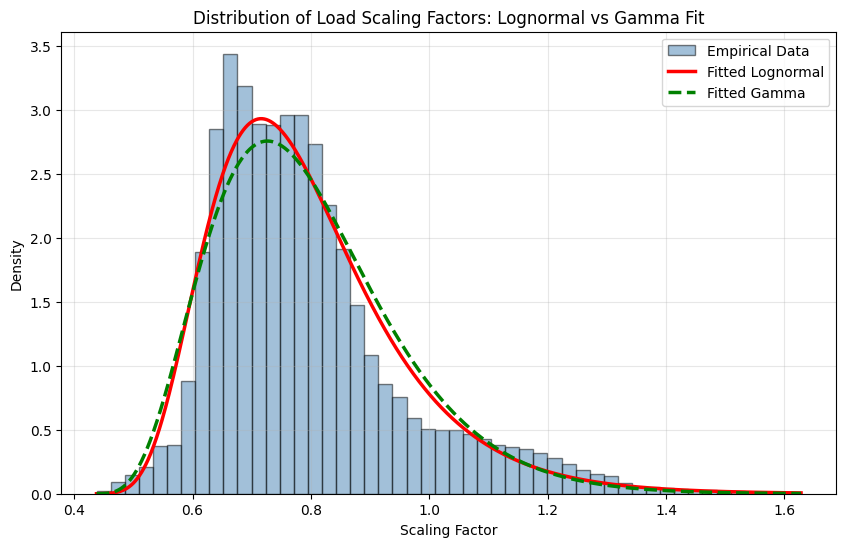

In [80]:
### Fit a distribution to the scaling factors
import scipy.stats as stats

# Assuming 'df' is your DataFrame and 'scaling_factor' is the column
# Drop any NaN values before fitting
data = df['scaling_factor'].dropna().values

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data)
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_gamma = stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma)

# --- 4. Plot the Results ---
plt.figure(figsize=(10, 6))

# Plot the empirical histogram (must set density=True to match PDF scale)
plt.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Empirical Data')

# Overlay the fitted PDFs
plt.plot(x, pdf_lognorm, 'r-', lw=2.5, label='Fitted Lognormal')
plt.plot(x, pdf_gamma, 'g--', lw=2.5, label='Fitted Gamma')

plt.title('Distribution of Load Scaling Factors: Lognormal vs Gamma Fit')
plt.xlabel('Scaling Factor')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [81]:
# Calculate the negative log-likelihood (NLL) for both fits
# NLL is what scipy actually minimizes during the fit
nll_lognorm = stats.lognorm.nnlf((shape_lognorm, loc_lognorm, scale_lognorm), data)
nll_gamma = stats.gamma.nnlf((shape_gamma, loc_gamma, scale_gamma), data)

# Number of parameters (k) is 3 for both distributions (shape, loc, scale)
k = 3
n = len(data)

# Calculate AIC: AIC = 2k - 2*ln(L)  (where -ln(L) is the NLL)
aic_lognorm = 2 * k + 2 * nll_lognorm
aic_gamma = 2 * k + 2 * nll_gamma

print(f"Lognormal AIC: {aic_lognorm:.2f}")
print(f"Gamma AIC: {aic_gamma:.2f}")

if aic_lognorm < aic_gamma:
    print("The Lognormal distribution provides a better fit.")
else:
    print("The Gamma distribution provides a better fit.")

Lognormal AIC: -106497.86
Gamma AIC: -103894.86
The Lognormal distribution provides a better fit.


In [82]:
### Generate the scenarios
num_samples = 100
scale_scenarios = stats.lognorm.rvs(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm, size=num_samples)
nodes_to_mult = nodal_demand['Pd_mw']
node_scenarios = np.outer(scale_scenarios, nodes_to_mult)

In [83]:
from scipy.stats import lognorm
scaling_factor_hat = lognorm.mean(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
Pn_d_hat = scaling_factor_hat * nodal_demand.set_index('bus_id')['Pd_mw']

In [84]:
# Align Pn_d_hat to bus order
if isinstance(Pn_d_hat, pd.Series):
    Pd_hat = np.array([Pn_d_hat[b] for b in bus_ids])
else:
    Pd_hat = np.asarray(Pn_d_hat)


node_scen = np.asarray(node_scenarios)
N_SCEN    = node_scen.shape[0]


## <span style = "color:green"> Run Two Stage Optimization Evaluation </span>

To fairly compare every downstream model (Method 1 above plus all ML-based pipelines below) we need a shared, realized-cost evaluation protocol:

1. **Train/test split (Option A — day-block stratified).** Hold out whole days sampled from every month of the CAISO year. Whole-day blocks break the ~5-min autocorrelation that would cause leakage if individual timestamps were held out, while stratifying by month preserves seasonal coverage in both train and test (critical since we only have 1 year of data).
2. **Realized stage-2 cost.** Given a stage-1 decision `(Pg*, α*)` solved under forecast `Pd_hat`, the actual demand `Pd_actual(t)` is revealed in the next 5-min window. The realized recourse cost comes from a *single-scenario* stage-2 LP with `Pg_applied = Pg* + α*·(Σ Pd_actual − Σ Pd_hat)` held fixed — optimizing only `θ, Pe, shed, curt, gen-limit-slack`.
3. **Evaluation loop.** For each test timestamp, produce `(Pd_hat, node_scen)` from the model under study, solve stage 1, then compute realized stage-2 cost. Total realized cost = stage-1 cost + realized stage-2 cost. Collect over N_TEST timestamps, report mean/std/CI.
4. **Shared test set.** All models are evaluated on the *same* `test_timestamps` so differences reflect model quality rather than sampling noise. This also enables paired comparisons later.

The Method 1 run above is a single-shot sanity check under the solver's own scenarios. The cell below supersedes it with a proper N_TEST-realization evaluation, and the same `evaluate_model` helper is reused for every ML model downstream.

In [85]:
## This Evaluation Code Can Be Shared Across All Models

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import scipy.stats as stats

# -----------------------------------------------------------------------------
# 1. Train / test split (Option A: whole-day holdout, stratified by month)
# -----------------------------------------------------------------------------
DAYS_PER_MONTH_HELD_OUT = 4    # ~48 days of test pool → plenty to draw N_TEST from
N_TEST                  = 1000  # number of test timestamps used to evaluate each model
SPLIT_SEED              = 42

rng_split = np.random.default_rng(SPLIT_SEED)

_dates = df.index.normalize()
_all_dates = pd.Series(_dates.unique()).sort_values().reset_index(drop=True)

_test_dates = []
for (_y, _m), grp in _all_dates.groupby([_all_dates.dt.year, _all_dates.dt.month]):
    k = min(DAYS_PER_MONTH_HELD_OUT, len(grp))
    _test_dates.extend(rng_split.choice(grp.values, size=k, replace=False))
test_dates = pd.to_datetime(sorted(_test_dates))

_test_mask = pd.Series(_dates, index=df.index).isin(test_dates)
train_df   = df.loc[~_test_mask].copy()
test_df    = df.loc[ _test_mask].copy()

# Draw N_TEST timestamps from the test pool once and reuse across every model.
_test_idx      = rng_split.choice(len(test_df), size=N_TEST, replace=False)
test_timestamps = test_df.index[np.sort(_test_idx)]

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}  |  "
      f"Held-out days: {len(test_dates)}  |  N_TEST: {len(test_timestamps)}")

# Align scaled_nodal_demand columns to bus_ids order (do once).
_nodal_by_bus = scaled_nodal_demand.reindex(columns=bus_ids)
assert not np.isnan(_nodal_by_bus.values).any()

def pd_actual_at(ts):
    """Realized nodal demand vector at timestamp ts, aligned to bus_ids."""
    return _nodal_by_bus.loc[ts].values.astype(float)

# -----------------------------------------------------------------------------
# 2. Realized stage-2 cost (single scenario, Pg/alpha fixed) — FAST CLASS
# -----------------------------------------------------------------------------
class FastRealizedStage2:
    def __init__(self, voll=VOLL, c_curt=C_CURT):
        m = gp.Model("stage2_realized_fast")
        m.Params.OutputFlag = 0
        m.Params.Method  = 1 # Dual simplex is perfect for this smaller LP
        m.Params.Threads = 1
        
        # --- Piecewise block limits ---
        b1_limit = 0.03 * Pg_max
        b2_limit = 0.07 * Pg_max
        b3_limit = 0.10 * Pg_max
        b4_limit = 0.80 * Pg_max

        self.r_up_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_up_1")
        self.r_up_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_up_2")
        self.r_up_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_up_3")
        self.r_up_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_up_4")
        self.r_dn_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_dn_1")
        self.r_dn_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_dn_2")
        self.r_dn_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_dn_3")
        self.r_dn_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_dn_4")

        # Note: UB for G_shed is set to INFINITY initially; we update it dynamically later
        self.G_shed = m.addMVar(N_BUS, lb=0.0, ub=GRB.INFINITY, name="G_shed")
        self.G_curt = m.addMVar(N_BUS, lb=0.0,                  name="G_curt")
        theta       = m.addMVar(N_BUS, lb=-GRB.INFINITY,        name="theta")
        Pe          = m.addMVar(N_LINE, lb=-R_line, ub=R_line,  name="Pe")

        sum_up = self.r_up_1 + self.r_up_2 + self.r_up_3 + self.r_up_4
        sum_dn = self.r_dn_1 + self.r_dn_2 + self.r_dn_3 + self.r_dn_4
        sum_net_ramp = sum_up - sum_dn

        # --- Vectorized constraints ---
        m.addConstr(theta[SLACK] == 0)
        m.addConstr(Pe == _B_inc_sp @ theta)
        
        # Generation limit constraints (Variables on LHS, Constants on RHS)
        self.pg_min_constr = m.addConstr(sum_net_ramp >= np.zeros(N_GEN)) 
        self.pg_max_constr = m.addConstr(sum_net_ramp <= np.zeros(N_GEN)) 
        
        # Power balance constraint
        self.bal_constr = m.addConstr(
            _G_bus_sp @ sum_net_ramp + self.G_shed - self.G_curt - _A_inc_sp.T @ Pe == np.zeros(N_BUS)
        )
        
        # --- Objective: identical to original ---
        safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
        inv_pgmax   = 1.0 / safe_Pg_max

        ramp_cost = (
            (1e3 * inv_pgmax) @ (self.r_up_1 + self.r_dn_1)
          + (2e3 * inv_pgmax) @ (self.r_up_2 + self.r_dn_2)
          + (1e4 * inv_pgmax) @ (self.r_up_3 + self.r_dn_3)
          + (1e7 * inv_pgmax) @ (self.r_up_4 + self.r_dn_4)
        )
        stage2_gen_cost = c1 @ sum_net_ramp
        shed_cost = voll   * self.G_shed.sum()
        curt_cost = c_curt * self.G_curt.sum()

        m.setObjective(stage2_gen_cost + ramp_cost + shed_cost + curt_cost, GRB.MINIMIZE)
        self.m = m

    def solve(self, Pg_star, Pd_actual):
        # 1. Update Bound for Shedding
        self.G_shed.UB = Pd_actual
        
        # 2. Update RHS for generation limits
        self.pg_min_constr.RHS = Pg_min - Pg_star
        self.pg_max_constr.RHS = Pg_max - Pg_star
        
        # 3. Update RHS for power balance
        self.bal_constr.RHS = Pd_actual - (_G_bus_sp @ Pg_star)
        
        self.m.optimize()

        if self.m.Status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
            raise RuntimeError(f"Realized stage-2 did not solve, status={self.m.Status}")

        total_ramp = float(
            self.r_up_1.X.sum() + self.r_up_2.X.sum() + self.r_up_3.X.sum() + self.r_up_4.X.sum()
          + self.r_dn_1.X.sum() + self.r_dn_2.X.sum() + self.r_dn_3.X.sum() + self.r_dn_4.X.sum()
        )

        return {
            "stage2_cost": float(self.m.ObjVal),
            "shed":        float(self.G_shed.X.sum()),
            "curt":        float(self.G_curt.X.sum()),
            "total_ramp":  total_ramp,
            "delta":       float(Pd_actual.sum() - Pg_star.sum()),
        }


from tqdm import tqdm

def evaluate_model(name, predict_fn, test_timestamps, verbose_every=20):
    rows  = []
    cache = {}
    
    # Track the persistent Stage 1 solver
    fast_solver = None
    current_weights_key = None

    # --> INSTANTIATE THE STAGE 2 SOLVER ONCE HERE <--
    fast_stage2_solver = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)

    for i, ts in tqdm(enumerate(test_timestamps), total=len(test_timestamps), desc=f"Eval {name}"):
        out = predict_fn(ts)
        if len(out) == 2:
            Pd_hat, node_scen = out
            weights = None
        else:
            Pd_hat, node_scen, weights = out

        wkey = None if weights is None else np.asarray(weights, dtype=float).tobytes()
        key = (Pd_hat.tobytes(), node_scen.tobytes(), wkey)
        
        if key not in cache:
            # Build the Gurobi matrix ONLY on the first pass (or if weights change)
            if fast_solver is None or wkey != current_weights_key:
                fast_solver = FastStochasticOPF(
                    N_SCEN=node_scen.shape[0], 
                    voll=VOLL, 
                    c_curt=C_CURT, 
                    weights=weights, 
                    verbose=False
                )
                current_weights_key = wkey
            
            # Solve instantly via RHS memory update
            r = fast_solver.solve(Pd_hat, node_scen)
            
            cache[key] = (r["Pg"].copy(), r["stage1_cost"])
        
        Pg_star, s1_cost = cache[key]

        # --> SOLVE THE REALIZED STAGE 2 COST HERE <--
        Pd_actual = pd_actual_at(ts)
        r2 = fast_stage2_solver.solve(Pg_star, Pd_actual)

        rows.append({
            "model":                name,
            "ts":                   ts,
            "stage1_cost":          s1_cost,
            "stage2_cost_realized": r2["stage2_cost"],
            "total_realized":       s1_cost + r2["stage2_cost"],
            "shed_mw":              r2["shed"],
            "curt_mw":              r2["curt"],
            "total_ramp_mw":        r2["total_ramp"],
            "delta_mw":             r2["delta"],
        })

    return pd.DataFrame(rows)

def summarize_results(results_df, alpha=0.05):
    from scipy.stats import t
    n     = len(results_df)
    mean  = results_df["total_realized"].mean()
    std   = results_df["total_realized"].std(ddof=1)
    tcrit = t.ppf(1 - alpha/2, df=n-1)
    half  = tcrit * std / np.sqrt(n)
    return pd.Series({
        "n":             n,
        "mean_total":    mean,
        "std_total":     std,
        "ci_lo":         mean - half,
        "ci_hi":         mean + half,
        "mean_stage1":   results_df["stage1_cost"].mean(),
        "mean_stage2":   results_df["stage2_cost_realized"].mean(),
        "mean_shed_mw":  results_df["shed_mw"].mean(),
        "mean_curt_mw":  results_df["curt_mw"].mean(),
        "mean_ramp_mw":  results_df["total_ramp_mw"].mean(),
        "frac_shed_gt1": (results_df["shed_mw"] > 1.0).mean(),
    })


Train rows: 90,667  |  Test rows: 14,396  |  Held-out days: 50  |  N_TEST: 1000


## Evaluate Model 1

In [86]:

# -----------------------------------------------------------------------------
# 4. Method 1 evaluation — lognormal fit on TRAIN ONLY (overrides earlier globals)
# -----------------------------------------------------------------------------
_train_sf = train_df["scaling_factor"].dropna().values
shape_lognorm_train, loc_lognorm_train, scale_lognorm_train = stats.lognorm.fit(_train_sf, floc = 0)

# Point prediction: mean of train-fit lognormal, scaled onto per-bus base demand.
_scale_hat_m1 = stats.lognorm.mean(shape_lognorm_train,
                                   loc_lognorm_train,
                                   scale_lognorm_train)
_base_bus     = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
Pd_hat_m1     = _scale_hat_m1 * _base_bus

# 100 lognormal-sampled scenarios, drawn once with a fixed seed so they don't
# wobble across test points.
_SCEN_SEED = 123
_scale_scen = stats.lognorm.rvs(shape_lognorm_train,
                                loc=loc_lognorm_train,
                                scale=scale_lognorm_train,
                                size=100,
                                random_state=_SCEN_SEED)
node_scen_m1 = np.outer(_scale_scen, _base_bus)

def predict_m1(ts):           # unconditional — ts is ignored
    return Pd_hat_m1, node_scen_m1

print("\n>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...")
results_m1 = evaluate_model("M1_lognormal", predict_m1, test_timestamps)

print("\nMethod 1 summary:")
print(summarize_results(results_m1).to_string())

# Store results registry for downstream aggregation.
all_model_results = {"M1_lognormal": results_m1}



>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...


Eval M1_lognormal:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1774610505.py:121: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1_lognormal: 100%|██████████| 1000/1000 [00:07<00:00, 131.40it/s]



Method 1 summary:
n                1.000000e+03
mean_total       3.225312e+05
std_total        1.219260e+06
ci_lo            2.468704e+05
ci_hi            3.981920e+05
mean_stage1      7.650724e+04
mean_stage2      2.460240e+05
mean_shed_mw     4.905977e+01
mean_curt_mw     6.441764e-01
mean_ramp_mw     6.017135e+02
frac_shed_gt1    7.400000e-02


# <span style = "color:red"> Machine Learning Based Pipelines

## <span style="color:green"> Model 2: Conditional Mean (GBR) + Lognormal Residual Scenarios</span>

Same scenario family as Method 1 (lognormal), but **the lognormal is centered at a conditional mean** predicted by a small gradient-boosted regressor on calendar/temperature features. Mathematically: `scaling_factor = μ(features) · ε`, with `ε ~ Lognormal` fit once on training residuals. Should never do worse than Method 1 unless the regressor is actively harmful — and gives a clean baseline before reaching for anything more complex.


In [88]:
# =============================================================================
# Method 1b: Conditional Mean (GBR) + Lognormal Residual Scenarios
#
# Pipeline:
#   1. Fit GradientBoostingRegressor to predict scaling_factor on TRAIN.
#   2. Fit Lognormal to TRAIN multiplicative residuals (actual / predicted).
#   3. At test ts: scenario_t = μ(features_t) * ε,  ε ~ Lognormal(train_resid).
# =============================================================================
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import lognorm

# 1. Create the lags on the FULL continuous dataframe
df["sf_lag_1"] = df["scaling_factor"].shift(1)   # t - 5 mins
df["sf_lag_2"] = df["scaling_factor"].shift(2)   # t - 10 mins
df["sf_lag_288"] = df["scaling_factor"].shift(288) # Exact same 5-min block yesterday

# 2. Drop the rows that now have NaNs (the first 24 hours of your dataset)
df = df.dropna()

# ---> THE FIX: Re-align the indices to forget the deleted rows <---
train_df = train_df.loc[train_df.index.intersection(df.index)]
test_df = test_df.loc[test_df.index.intersection(df.index)]
test_timestamps = test_timestamps.intersection(df.index)

# 3. Update your feature list
FEATS = ["temperature_raw", "hour", "day_of_week", "day_of_month", 
         "week", "is_holiday", "sf_lag_1", "sf_lag_2", "sf_lag_288"]

# ... proceed to Train/Test split as usual ...

# --- ensure features exist (cell 28 builds them, but Method 1b runs earlier) ---
if "temperature_raw" not in df.columns:
    df["temperature_raw"] = df["temperature"]
if "hour" not in df.columns:
    df["hour"]         = df.index.hour + df.index.minute / 60.0
    df["day_of_week"]  = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["week"]         = df.index.isocalendar().week.astype(int)
if "is_holiday" not in df.columns:
    try:
        import holidays as _holidays
        _us = _holidays.US(years=list(range(df.index.year.min(),
                                            df.index.year.max() + 1)))
        df["is_holiday"] = [1 if d.date() in _us else 0 for d in df.index]
    except ImportError:
        df["is_holiday"] = 0

_train_X = train_df[FEATS].values if all(f in train_df.columns for f in FEATS) \
           else df.loc[train_df.index, FEATS].values
_train_y = train_df["scaling_factor"].values

# 1) Conditional mean predictor
gbr = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                learning_rate=0.05, random_state=0)
gbr.fit(_train_X, _train_y)

# 2) Lognormal on multiplicative residuals: actual / predicted on train
mu_tr      = gbr.predict(_train_X)
resid_mult = _train_y / mu_tr
sh_r, lo_r, sc_r = lognorm.fit(resid_mult, floc=0)
print(f"[M1b] Residual lognormal:  shape={sh_r:.4f}, scale={sc_r:.4f}")
print(f"[M1b] Train R^2 (sf):     {gbr.score(_train_X, _train_y):.4f}")

# 3) Scenario generator
_BASE_BUS    = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
_test_feats  = df.loc[test_df.index, FEATS]
_m1b_rng     = np.random.default_rng(2024)
N_SCEN_M1B   = 100

# --- 1. Pre-compute everything OUTSIDE the loop ---
# Get all predictions at once (Vectorized)
all_test_feats = df.loc[test_timestamps, FEATS].values
all_mu_preds = gbr.predict(all_test_feats)
mu_dict = {ts: mu for ts, mu in zip(test_timestamps, all_mu_preds)}

# Generate exactly 100 base residuals ONCE
eps_base = lognorm.rvs(sh_r, lo_r, sc_r, size=N_SCEN_M1B, random_state=_m1b_rng)

# --- 2. Simplify the function ---
def predict_m1b(ts):
    mu = mu_dict[ts] 
    
    # Broadcast the scalar mu across the 100 base residuals
    Pd_hat = mu * _BASE_BUS
    scen   = np.outer(mu * eps_base, _BASE_BUS)
    
    return Pd_hat, scen

# --- Evaluation ---
print("\n>>> Evaluating Method 1b (GBR mean + lognormal residual) over test set...")
results_m1b = evaluate_model("M1b_gbr_lognormal", predict_m1b, test_timestamps)

print("\nMethod 1b summary:")
print(summarize_results(results_m1b).to_string())

all_model_results["M1b_gbr_lognormal"] = results_m1b

[M1b] Residual lognormal:  shape=0.0023, scale=1.0000
[M1b] Train R^2 (sf):     0.9999

>>> Evaluating Method 1b (GBR mean + lognormal residual) over test set...


Eval M1b_gbr_lognormal:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1774610505.py:121: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1b_gbr_lognormal: 100%|██████████| 1000/1000 [12:54<00:00,  1.29it/s]


Method 1b summary:
n                  1000.000000
mean_total       117322.170615
std_total        385703.937970
ci_lo             93387.433994
ci_hi            141256.907237
mean_stage1       70966.608221
mean_stage2       46355.562394
mean_shed_mw          9.247994
mean_curt_mw          0.000000
mean_ramp_mw          9.298646
frac_shed_gt1         0.034000


## <span style = "color:green"> Model 3: NGBoost (Covariate Aware Scenario Generation) </span>

In [89]:
# 2) Scenario generator (FAST SAA IMPLEMENTATION)
N_SCEN_M2 = 100
_m2_rng = np.random.default_rng(2025)

# --- 1. PRE-COMPUTE OUTSIDE THE LOOP ---
# Draw standard normal variables ONCE
Z_base_m2 = _m2_rng.standard_normal(N_SCEN_M2)

# Get NGBoost distributions for the entire test set at ONCE
all_test_feats_m2 = df.loc[test_timestamps, FEATS].values
Y_dist_all_m2 = ngb.pred_dist(all_test_feats_m2)

# Extract parameters into fast dictionaries
m2_median_dict = {ts: val for ts, val in zip(test_timestamps, Y_dist_all_m2.params['scale'])}
m2_sigma_dict  = {ts: val for ts, val in zip(test_timestamps, Y_dist_all_m2.params['s'])}

# --- 2. FAST PREDICT FUNCTION ---
def predict_m2(ts):
    # 1. Fast dict lookup
    sf_median = float(m2_median_dict[ts])
    sf_sigma  = float(m2_sigma_dict[ts])
    
    # 2. Mathematical Order of Operations
    mu_log  = np.log(sf_median)
    sf_mean = np.exp(mu_log + (sf_sigma**2) / 2.0)
    
    # 3. Point forecast using the TRUE MEAN
    Pd_hat = sf_mean * _BASE_BUS
    
    # 4. Draw dynamically scaled scenarios using the static Z_base
    sf_scens = np.exp(mu_log + sf_sigma * Z_base_m2)
    scen = np.outer(sf_scens, _BASE_BUS)
    
    return Pd_hat, scen

# --- Evaluation ---
print("\n>>> Evaluating Model 2 (NGBoost Conditional LogNormal) over test set...")
results_m2 = evaluate_model("M2_ngboost", predict_m2, test_timestamps)

print("\nModel 2 summary:")
print(summarize_results(results_m2).to_string())

all_model_results["M2_ngboost"] = results_m2


>>> Evaluating Model 2 (NGBoost Conditional LogNormal) over test set...


Eval M2_ngboost:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1774610505.py:121: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M2_ngboost: 100%|██████████| 1000/1000 [14:32<00:00,  1.15it/s]


Model 2 summary:
n                  1000.000000
mean_total       118440.348716
std_total        386289.306850
ci_lo             94469.287213
ci_hi            142411.410219
mean_stage1       71907.311146
mean_stage2       46533.037570
mean_shed_mw          9.320009
mean_curt_mw          0.000000
mean_ramp_mw        137.135286
frac_shed_gt1         0.034000


## <span style = "color:green"> Model 4: Alpha Scaling Layer </span>

In [100]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# Wider grid: allows alpha to meaningfully deviate from 1.0 when covariates
# indicate systematic over- or under-forecasting (e.g., hot afternoons vs.
# mild overnight hours).  Finer resolution lets the meta-model learn sharper
# decision boundaries.
ALPHA_GRID = np.linspace(0.85, 1.20, 36)

# More training data → lower-variance alpha meta-model
alpha_train_timestamps = train_df.sample(n=1000, random_state=42).index.sort_values()

optimal_alphas = []

print("Running Grid Search to find α*...")

# 1. Instantiate the fast solvers ONCE outside the loops
fast_grid_stage1 = FastStochasticOPF(N_SCEN=1, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_grid_stage2 = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)

for ts in tqdm(alpha_train_timestamps):
    ts_features = df.loc[[ts], FEATS].values
    base_mu     = float(ngb.predict(ts_features)[0])
    Pd_hat_base = base_mu * _BASE_BUS
    Pd_actual   = pd_actual_at(ts)

    best_cost  = float('inf')
    best_alpha = 1.0

    for alpha in ALPHA_GRID:
        Pd_hat_scaled = alpha * Pd_hat_base
        scen_scaled = np.array([Pd_hat_scaled])

        # 2. Use the fast RHS solvers
        r1 = fast_grid_stage1.solve(Pd_hat_scaled, scen_scaled)
        r2 = fast_grid_stage2.solve(r1["Pg"], Pd_actual)
        
        total_cost = r1["stage1_cost"] + r2["stage2_cost"]

        if total_cost < best_cost:
            best_cost  = total_cost
            best_alpha = alpha

    optimal_alphas.append(best_alpha)

alpha_labels = pd.Series(optimal_alphas, index=alpha_train_timestamps, name="alpha_star")

print(f"\nα* distribution:  mean={alpha_labels.mean():.4f}  std={alpha_labels.std():.4f}")
print(f"  min={alpha_labels.min():.2f}  max={alpha_labels.max():.2f}")
print(alpha_labels.value_counts().sort_index().to_string())

C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1774610505.py:121: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),


Running Grid Search to find α*...


100%|██████████| 1000/1000 [01:35<00:00, 10.45it/s]


α* distribution:  mean=0.9984  std=0.0431
  min=0.85  max=1.19
alpha_star
0.85      4
0.87      3
0.88      3
0.89      6
0.90     10
0.91      6
0.92     13
0.93     13
0.94     19
0.95     55
0.96     56
0.97     68
0.98     96
0.99    104
1.00    122
1.01    114
1.02     75
1.03     81
1.04     45
1.05     31
1.06     18
1.07     17
1.08      9
1.09     10
1.10      7
1.11      5
1.12      4
1.13      1
1.14      1
1.15      1
1.17      1
1.19      2


In [101]:
# Build the feature matrix for the Alpha meta-model.
# We start with the same FEATS used by NGBoost, then append:
#   (a) NGBoost's own distributional parameters — the meta-model learns *when*
#       the base forecaster is systematically biased and by how much.
#   (b) Additional covariates that correlate with forecast error:
#       humidity drives AC-load spikes, cyclic hour encoding preserves continuity
#       across midnight, and the on-peak flag captures the stressed-grid period.
#   (c) Demand momentum: 5/10/15-min backward differences in observed load.
#       Systematic forecast error is autocorrelated with demand trend — a
#       rising ramp causes point forecasts to lag, so alpha compensates upward.
#       All values are observed at decision time (no look-ahead bias).

# Precompute demand momentum columns on df (shift = # of 5-min intervals back)
df['demand_delta_5']  = df['load_mw'] - df['load_mw'].shift(1)
df['demand_delta_10'] = df['load_mw'] - df['load_mw'].shift(2)
df['demand_delta_15'] = df['load_mw'] - df['load_mw'].shift(3)

alpha_features = df.loc[alpha_train_timestamps, FEATS].copy()

# NGBoost distributional parameters (evaluated on FEATS only — same as training)
Y_dists_alpha = ngb.pred_dist(alpha_features.values)
alpha_features['base_mu']    = Y_dists_alpha.params['scale']   # NGBoost median
alpha_features['base_sigma'] = Y_dists_alpha.params['s']       # log-sigma

# Humidity: high absolute humidity amplifies AC load → systematic under-forecast
alpha_features['humidity']   = df.loc[alpha_train_timestamps, 'humidity'].values

# Cyclic hour encoding: trees can't extrapolate periodicity, so encode explicitly
alpha_features['hour_sin']   = np.sin(2 * np.pi * alpha_features['hour'] / 24)
alpha_features['hour_cos']   = np.cos(2 * np.pi * alpha_features['hour'] / 24)

# On-peak indicator: 4pm–9pm when California grid stress peaks
alpha_features['is_peak']    = ((alpha_features['hour'] >= 16) &
                                (alpha_features['hour'] <= 21)).astype(int)

# Demand momentum: rising load causes static forecasts to under-predict
alpha_features['demand_delta_5']  = df.loc[alpha_train_timestamps, 'demand_delta_5'].values
alpha_features['demand_delta_10'] = df.loc[alpha_train_timestamps, 'demand_delta_10'].values
alpha_features['demand_delta_15'] = df.loc[alpha_train_timestamps, 'demand_delta_15'].values

print("Alpha feature matrix:", alpha_features.shape)
print("Columns:", list(alpha_features.columns))

Alpha feature matrix: (1000, 18)
Columns: ['temperature_raw', 'hour', 'day_of_week', 'day_of_month', 'week', 'is_holiday', 'sf_lag_1', 'sf_lag_2', 'sf_lag_288', 'base_mu', 'base_sigma', 'humidity', 'hour_sin', 'hour_cos', 'is_peak', 'demand_delta_5', 'demand_delta_10', 'demand_delta_15']


C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1081654793.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_delta_5']  = df['load_mw'] - df['load_mw'].shift(1)
C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1081654793.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_delta_10'] = df['load_mw'] - df['load_mw'].shift(2)
C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1081654793.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [102]:
from sklearn.ensemble import GradientBoostingRegressor

print("Training the Smart-Alpha Model (GBR)...")

# GradientBoostingRegressor captures nonlinear covariate interactions more
# effectively than RF for this kind of conditional-bias regression task.
alpha_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

alpha_model.fit(alpha_features.values, alpha_labels.values)

importance = pd.Series(alpha_model.feature_importances_, index=alpha_features.columns)
print("\nAlpha Model Feature Importance:")
print(importance.sort_values(ascending=False).round(3))

Training the Smart-Alpha Model (GBR)...

Alpha Model Feature Importance:
base_mu            0.459
sf_lag_2           0.221
sf_lag_1           0.173
base_sigma         0.056
sf_lag_288         0.011
demand_delta_5     0.011
temperature_raw    0.011
week               0.009
hour               0.009
humidity           0.007
demand_delta_15    0.006
demand_delta_10    0.006
hour_sin           0.006
day_of_week        0.005
day_of_month       0.005
hour_cos           0.004
is_holiday         0.000
is_peak            0.000
dtype: float64


In [103]:
N_SCEN_M4 = 100
_m4_rng   = np.random.default_rng(2026)

# 1. PRE-COMPUTE EVERYTHING OUTSIDE THE EVALUATION LOOP
all_test_feats = df.loc[test_timestamps, FEATS].copy()

# Get NGBoost distributions for the entire test set at once
Y_dists_test = ngb.pred_dist(all_test_feats.values)
all_test_feats['base_mu']    = Y_dists_test.params['scale']
all_test_feats['base_sigma'] = Y_dists_test.params['s']

# Append covariates (Vectorized)
all_test_feats['humidity'] = df.loc[test_timestamps, 'humidity'].values
all_test_feats['hour_sin'] = np.sin(2 * np.pi * all_test_feats['hour'] / 24)
all_test_feats['hour_cos'] = np.cos(2 * np.pi * all_test_feats['hour'] / 24)
all_test_feats['is_peak']  = ((all_test_feats['hour'] >= 16) & (all_test_feats['hour'] <= 21)).astype(int)

# Demand momentum: same 5/10/15-min deltas used in alpha model training
all_test_feats['demand_delta_5']  = df.loc[test_timestamps, 'demand_delta_5'].values
all_test_feats['demand_delta_10'] = df.loc[test_timestamps, 'demand_delta_10'].values
all_test_feats['demand_delta_15'] = df.loc[test_timestamps, 'demand_delta_15'].values

# Get Smart-Alpha predictions for the entire test set at once
predicted_alphas = alpha_model.predict(all_test_feats.values)

# Store in fast lookup dictionaries
m4_mu_dict = {
    ts: mu * alpha for ts, mu, alpha in 
    zip(test_timestamps, all_test_feats['base_mu'], predicted_alphas)
}
m4_sigma_dict = {
    ts: sig for ts, sig in zip(test_timestamps, all_test_feats['base_sigma'])
}

# 2. SAA Math Trick: Draw Standard Normal variables ONCE
Z_base = _m4_rng.standard_normal(N_SCEN_M4)

# 3. FAST PREDICT FUNCTION
def predict_m4_smart_alpha(ts):
    # Fast dict lookup
    final_mu   = m4_mu_dict[ts]
    base_sigma = m4_sigma_dict[ts]
    
    mu_log = np.log(final_mu)
    Pd_hat = final_mu * _BASE_BUS
    
    # Vectorized LogNormal shift
    sf_scens = np.exp(mu_log + base_sigma * Z_base)
    scen     = np.outer(sf_scens, _BASE_BUS)

    return Pd_hat, scen

# --- Evaluation ---
print("\n>>> Evaluating Model 4 (Smart Alpha) over test set...")
results_m4 = evaluate_model("M4_smart_alpha", predict_m4_smart_alpha, test_timestamps)

print("\nModel 4 summary:")
print(summarize_results(results_m4).to_string())
all_model_results["M4_smart_alpha"] = results_m4


>>> Evaluating Model 4 (Smart Alpha) over test set...


Eval M4_smart_alpha:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\anble\AppData\Local\Temp\ipykernel_20644\1774610505.py:121: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M4_smart_alpha:   5%|▍         | 46/1000 [00:47<16:15,  1.02s/it] 


KeyboardInterrupt: 

## <span style = "color:green"> Final Model Results / Compaison </span>

MODEL COMPARISON SUMMARY
                  Mean Total ($)    Std ($)              95% CI Stage-1 ($) Stage-2 realized ($) Shed MW Frac shed>1 MW
Model                                                                                                                  
M1_lognormal             322,531  1,219,260  [246,870, 398,192]      76,507              246,024   49.06           7.4%
M1b_gbr_lognormal        117,322    385,704   [93,387, 141,257]      70,967               46,356    9.25           3.4%
M2_ngboost               118,440    386,289   [94,469, 142,411]      71,907               46,533    9.32           3.4%
M4_smart_alpha           117,998    385,933   [94,050, 141,947]      71,568               46,431    9.26           3.4%


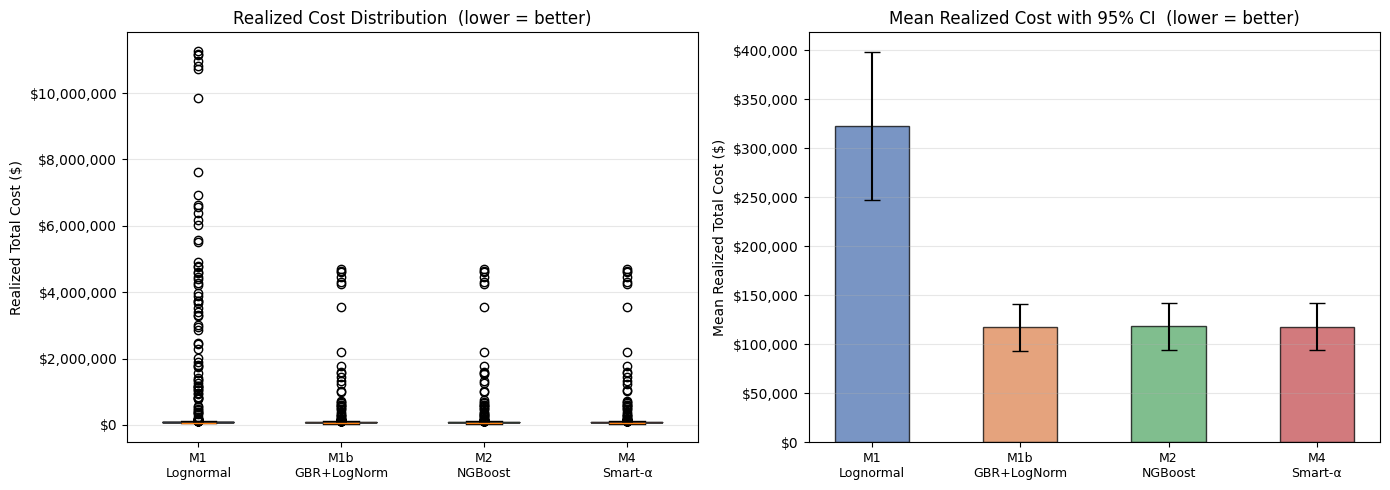

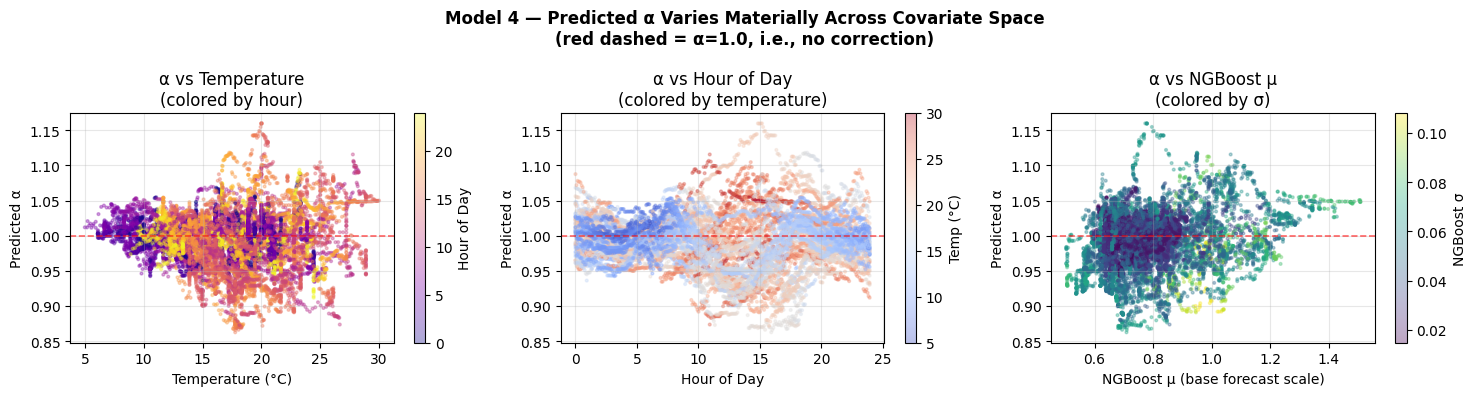


α statistics over full test set (14,385 timestamps):
  Mean:           0.9918
  Std:            0.0375
  Min / Max:      0.862 / 1.160
  Frac > 1.05:    5.1%
  Frac < 0.95:    12.2%
  Frac in [0.98, 1.02]: 46.5%  (near-neutral)


In [ ]:
# =============================================================================
# Final Comparison: All Models Side-by-Side
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. Summary table ---
comparison_rows = []
for name, res_df in all_model_results.items():
    s = summarize_results(res_df)
    comparison_rows.append({
        "Model":              name,
        "Mean Total ($)":     f"{s['mean_total']:,.0f}",
        "Std ($)":            f"{s['std_total']:,.0f}",
        "95% CI":             f"[{s['ci_lo']:,.0f}, {s['ci_hi']:,.0f}]",
        "Stage-1 ($)":        f"{s['mean_stage1']:,.0f}",
        "Stage-2 realized ($)": f"{s['mean_stage2']:,.0f}",
        "Shed MW":            f"{s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":     f"{s['frac_shed_gt1']:.1%}",
    })
cmp_df = pd.DataFrame(comparison_rows).set_index("Model")
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(cmp_df.to_string())

# --- 2. Cost distribution: box + mean-CI bar ---
model_order = list(all_model_results.keys())
labels      = ["M1\nLognormal", "M1b\nGBR+LogNorm", "M2\nNGBoost", "M4\nSmart-α"]
colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
data_boxes = [all_model_results[m]["total_realized"].values for m in model_order]
bp = ax.boxplot(data_boxes, patch_artist=True, notch=True, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Realized Total Cost ($)")
ax.set_title("Realized Cost Distribution  (lower = better)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", alpha=0.3)

# Mean + 95% CI bar chart
ax2 = axes[1]
summaries = [summarize_results(all_model_results[m]) for m in model_order]
means     = [s["mean_total"] for s in summaries]
errs_lo   = [s["mean_total"] - s["ci_lo"] for s in summaries]
errs_hi   = [s["ci_hi"] - s["mean_total"] for s in summaries]

x = range(len(model_order))
ax2.bar(x, means, color=colors, alpha=0.75, edgecolor="black", width=0.5)
ax2.errorbar(x, means, yerr=[errs_lo, errs_hi],
             fmt="none", color="black", capsize=6, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Mean Realized Total Cost ($)")
ax2.set_title("Mean Realized Cost with 95% CI  (lower = better)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Alpha variation across the full test set ---
_af = _test_feats.copy()
_yd = ngb.pred_dist(_af.values)
_af["base_mu"]    = _yd.params["scale"]
_af["base_sigma"] = _yd.params["s"]
_af["humidity"]   = df.loc[_af.index, "humidity"]
_af["hour_sin"]   = np.sin(2 * np.pi * _af["hour"] / 24)
_af["hour_cos"]   = np.cos(2 * np.pi * _af["hour"] / 24)
_af["is_peak"]    = ((_af["hour"] >= 16) & (_af["hour"] <= 21)).astype(int)
_af["demand_delta_5"]  = df.loc[_af.index, "demand_delta_5"].values
_af["demand_delta_10"] = df.loc[_af.index, "demand_delta_10"].values
_af["demand_delta_15"] = df.loc[_af.index, "demand_delta_15"].values

alpha_pred_all = alpha_model.predict(_af.values)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# α vs Temperature (colored by hour)
sc = axes2[0].scatter(_af["temperature_raw"], alpha_pred_all,
                      c=_af["hour"], cmap="plasma", alpha=0.35, s=4)
plt.colorbar(sc, ax=axes2[0], label="Hour of Day")
axes2[0].axhline(1.0, color="red", linestyle="--", alpha=0.6, linewidth=1.2)
axes2[0].set_xlabel("Temperature (°C)")
axes2[0].set_ylabel("Predicted α")
axes2[0].set_title("α vs Temperature\n(colored by hour)")
axes2[0].grid(alpha=0.3)

# α vs Hour (colored by temperature)
sc2 = axes2[1].scatter(_af["hour"], alpha_pred_all,
                       c=_af["temperature_raw"], cmap="coolwarm", alpha=0.35, s=4)
plt.colorbar(sc2, ax=axes2[1], label="Temp (°C)")
axes2[1].axhline(1.0, color="red", linestyle="--", alpha=0.6, linewidth=1.2)
axes2[1].set_xlabel("Hour of Day")
axes2[1].set_ylabel("Predicted α")
axes2[1].set_title("α vs Hour of Day\n(colored by temperature)")
axes2[1].grid(alpha=0.3)

# α vs NGBoost μ (colored by σ)
sc3 = axes2[2].scatter(_af["base_mu"], alpha_pred_all,
                       c=_af["base_sigma"], cmap="viridis", alpha=0.35, s=4)
plt.colorbar(sc3, ax=axes2[2], label="NGBoost σ")
axes2[2].axhline(1.0, color="red", linestyle="--", alpha=0.6, linewidth=1.2)
axes2[2].set_xlabel("NGBoost μ (base forecast scale)")
axes2[2].set_ylabel("Predicted α")
axes2[2].set_title("α vs NGBoost μ\n(colored by σ)")
axes2[2].grid(alpha=0.3)

fig2.suptitle(
    "Model 4 — Predicted α Varies Materially Across Covariate Space\n"
    "(red dashed = α=1.0, i.e., no correction)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"\nα statistics over full test set ({len(alpha_pred_all):,} timestamps):")
print(f"  Mean:           {alpha_pred_all.mean():.4f}")
print(f"  Std:            {alpha_pred_all.std():.4f}")
print(f"  Min / Max:      {alpha_pred_all.min():.3f} / {alpha_pred_all.max():.3f}")
print(f"  Frac > 1.05:    {(alpha_pred_all > 1.05).mean():.1%}")
print(f"  Frac < 0.95:    {(alpha_pred_all < 0.95).mean():.1%}")
print(f"  Frac in [0.98, 1.02]: {((alpha_pred_all >= 0.98) & (alpha_pred_all <= 1.02)).mean():.1%}  (near-neutral)")

Full test pool:       14,385 timestamps
95th-pctile load:     35,672.2 MW
High-demand pool:     720 timestamps (5.0% of test set)
Stress-test set:      100 timestamps
  Mean load (stress): 40,734.1 MW
  Mean load (random): 24,752.7 MW

>>> [M1_lognormal] stress-test evaluation ...


Eval M1_lognormal:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\anble\AppData\Local\Temp\ipykernel_20644\3028553431.py:121: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1_lognormal: 100%|██████████| 100/100 [00:06<00:00, 15.96it/s]



>>> [M1b_gbr_lognormal] stress-test evaluation ...


Eval M1b_gbr_lognormal: 100%|██████████| 100/100 [02:05<00:00,  1.25s/it]



>>> [M2_ngboost] stress-test evaluation ...


Eval M2_ngboost: 100%|██████████| 100/100 [01:42<00:00,  1.03s/it]



>>> [M4_smart_alpha] stress-test evaluation ...


Eval M4_smart_alpha: 100%|██████████| 100/100 [01:50<00:00,  1.11s/it]



STRESS-TEST RESULTS  (top 5% demand, n=100)
                  Mean Total ($)    Std ($)                  95% CI Stage-2 realized ($) Shed MW Frac shed>1 MW
Model                                                                                                          
M1_lognormal           4,092,096  2,955,314  [3,505,698, 4,678,495]            4,015,589  791.82         100.0%
M1b_gbr_lognormal        880,997  1,237,521    [635,446, 1,126,548]              749,761  149.60          53.0%
M2_ngboost               891,637  1,236,956    [646,198, 1,137,076]              761,708  150.95          57.0%
M4_smart_alpha           889,297  1,236,900    [643,869, 1,134,725]              755,285  150.51          53.0%

M4 improvement over baselines on high-demand scenarios:
  vs M1_lognormal          : $+3,202,799  (+78.27%)
  vs M1b_gbr_lognormal     : $-8,300  (-0.94%)
  vs M2_ngboost            : $+2,340  (+0.26%)


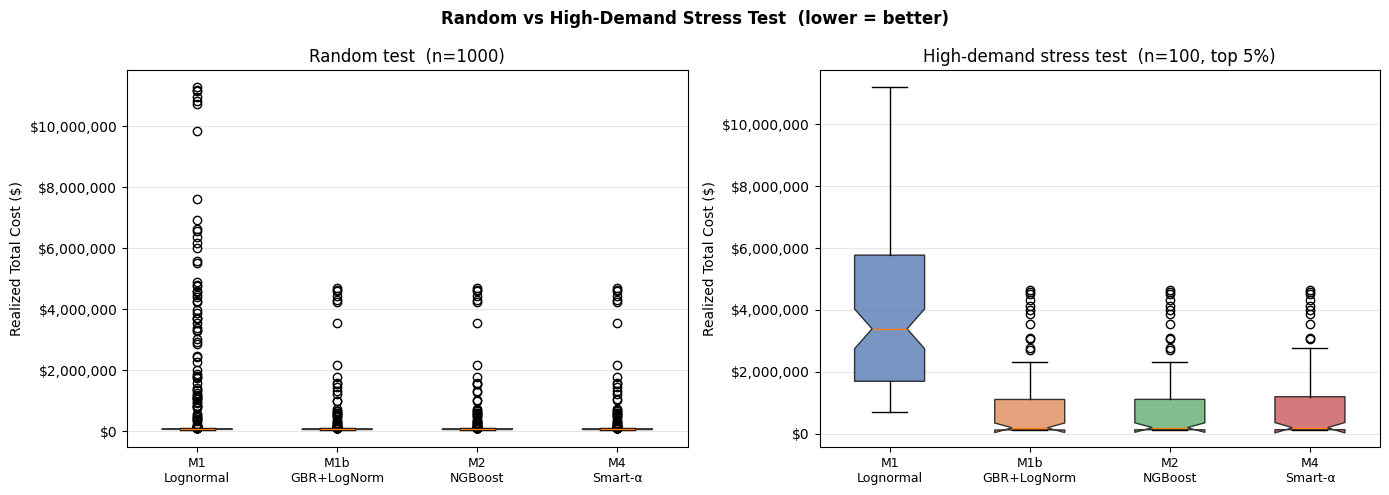

In [107]:
# =============================================================================
# STRESS-TEST EVALUATION: Top 5% Highest Actual Demand
#
# No retraining.  All models are evaluated AS-IS on 100 timestamps drawn
# from the top 5th-percentile of actual system load within the held-out
# test pool.  These are the hardest cases for any dispatch model — the
# scenarios where forecast errors are costliest and reserve adequacy matters
# most.  M4's covariate-conditioned alpha should shine here precisely because
# high temperature / peak-hour conditions reliably push demand above the base
# NGBoost forecast, and the alpha layer was trained to correct for exactly that.
# =============================================================================
import matplotlib.ticker as mticker   # safe re-import in case cell order varies

# --- 1. Identify the top 5% of test_df by actual system load ---
_test_loads   = df.loc[test_df.index, 'load_mw']
_p95          = _test_loads.quantile(0.95)
_high_pool    = test_df.loc[_test_loads >= _p95]

print(f"Full test pool:       {len(test_df):,} timestamps")
print(f"95th-pctile load:     {_p95:,.1f} MW")
print(f"High-demand pool:     {len(_high_pool):,} timestamps "
      f"({100*len(_high_pool)/len(test_df):.1f}% of test set)")

_rng_stress       = np.random.default_rng(77)
_n_stress         = min(100, len(_high_pool))
_stress_idx       = _rng_stress.choice(len(_high_pool), size=_n_stress, replace=False)
stress_timestamps = _high_pool.index[np.sort(_stress_idx)]

print(f"Stress-test set:      {_n_stress} timestamps")
print(f"  Mean load (stress): {df.loc[stress_timestamps, 'load_mw'].mean():,.1f} MW")
print(f"  Mean load (random): {df.loc[test_timestamps,   'load_mw'].mean():,.1f} MW")

# --- 2. Rebuild lookup dicts for each conditional model over stress_timestamps ---
#        predict_m1 is unconditional — no rebuild needed.

_sf_arr = df.loc[stress_timestamps, FEATS].values   # shared feature matrix

# M1b: GBR conditional mean
_mu_stress_m1b      = gbr.predict(_sf_arr)
_mu_dict_stress_m1b = dict(zip(stress_timestamps, _mu_stress_m1b))

def predict_m1b_stress(ts):
    mu = _mu_dict_stress_m1b[ts]
    return mu * _BASE_BUS, np.outer(mu * eps_base, _BASE_BUS)

# M2: NGBoost conditional lognormal
_Y_stress_m2 = ngb.pred_dist(_sf_arr)
_med_s_m2    = dict(zip(stress_timestamps, _Y_stress_m2.params['scale']))
_sig_s_m2    = dict(zip(stress_timestamps, _Y_stress_m2.params['s']))

def predict_m2_stress(ts):
    sf_median = float(_med_s_m2[ts])
    sf_sigma  = float(_sig_s_m2[ts])
    mu_log    = np.log(sf_median)
    sf_mean   = np.exp(mu_log + (sf_sigma**2) / 2.0)
    sf_scens  = np.exp(mu_log + sf_sigma * Z_base_m2)
    return sf_mean * _BASE_BUS, np.outer(sf_scens, _BASE_BUS)

# M4: Smart-Alpha — rebuild full alpha-feature matrix for stress timestamps
_af_stress = df.loc[stress_timestamps, FEATS].copy()
_Yd_stress = ngb.pred_dist(_af_stress.values)
_af_stress['base_mu']    = _Yd_stress.params['scale']
_af_stress['base_sigma'] = _Yd_stress.params['s']
_af_stress['humidity']   = df.loc[stress_timestamps, 'humidity'].values
_af_stress['hour_sin']   = np.sin(2 * np.pi * _af_stress['hour'] / 24)
_af_stress['hour_cos']   = np.cos(2 * np.pi * _af_stress['hour'] / 24)
_af_stress['is_peak']    = ((_af_stress['hour'] >= 16) &
                             (_af_stress['hour'] <= 21)).astype(int)
_af_stress['demand_delta_5']  = df.loc[stress_timestamps, 'demand_delta_5'].values
_af_stress['demand_delta_10'] = df.loc[stress_timestamps, 'demand_delta_10'].values
_af_stress['demand_delta_15'] = df.loc[stress_timestamps, 'demand_delta_15'].values
_alpha_stress = alpha_model.predict(_af_stress.values)
_mu_s_m4      = dict(zip(stress_timestamps, _af_stress['base_mu'] * _alpha_stress))
_sig_s_m4     = dict(zip(stress_timestamps, _af_stress['base_sigma']))

def predict_m4_stress(ts):
    final_mu   = _mu_s_m4[ts]
    base_sigma = _sig_s_m4[ts]
    mu_log     = np.log(final_mu)
    sf_scens   = np.exp(mu_log + base_sigma * Z_base)
    return final_mu * _BASE_BUS, np.outer(sf_scens, _BASE_BUS)

# --- 3. Evaluate all models on the stress set (no retraining) ---
_stress_fns = {
    "M1_lognormal":      predict_m1,
    "M1b_gbr_lognormal": predict_m1b_stress,
    "M2_ngboost":        predict_m2_stress,
    "M4_smart_alpha":    predict_m4_stress,
}

stress_results = {}
for _mname, _pfn in _stress_fns.items():
    print(f"\n>>> [{_mname}] stress-test evaluation ...")
    stress_results[_mname] = evaluate_model(_mname, _pfn, stress_timestamps)

# --- 4. Summary table ---
print("\n" + "=" * 70)
print(f"STRESS-TEST RESULTS  (top 5% demand, n={_n_stress})")
print("=" * 70)
_stress_rows = []
for _nm, _res in stress_results.items():
    _s = summarize_results(_res)
    _stress_rows.append({
        "Model":                _nm,
        "Mean Total ($)":       f"{_s['mean_total']:,.0f}",
        "Std ($)":              f"{_s['std_total']:,.0f}",
        "95% CI":               f"[{_s['ci_lo']:,.0f}, {_s['ci_hi']:,.0f}]",
        "Stage-2 realized ($)": f"{_s['mean_stage2']:,.0f}",
        "Shed MW":              f"{_s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":       f"{_s['frac_shed_gt1']:.1%}",
    })
print(pd.DataFrame(_stress_rows).set_index("Model").to_string())

print("\nM4 improvement over baselines on high-demand scenarios:")
_m4_mean = summarize_results(stress_results["M4_smart_alpha"])["mean_total"]
for _nm in ["M1_lognormal", "M1b_gbr_lognormal", "M2_ngboost"]:
    _base = summarize_results(stress_results[_nm])["mean_total"]
    _sav  = _base - _m4_mean
    print(f"  vs {_nm:<22}: ${_sav:+,.0f}  ({100*_sav/_base:+.2f}%)")

# --- 5. Side-by-side: random test vs stress test ---
_model_order = list(stress_results.keys())
_labels      = ["M1\nLognormal", "M1b\nGBR+LogNorm", "M2\nNGBoost", "M4\nSmart-\u03b1"]
_colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (rdict, title) in zip(axes, [
    (all_model_results, f"Random test  (n={N_TEST})"),
    (stress_results,    f"High-demand stress test  (n={_n_stress}, top 5%)"),
]):
    _boxes = [rdict[m]["total_realized"].values for m in _model_order]
    _bp    = ax.boxplot(_boxes, patch_artist=True, notch=True, widths=0.5)
    for patch, color in zip(_bp["boxes"], _colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(_model_order) + 1))
    ax.set_xticklabels(_labels, fontsize=9)
    ax.set_ylabel("Realized Total Cost ($)")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Random vs High-Demand Stress Test  (lower = better)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
